In [1]:
import os
os.chdir("/home/raufie/work/dynamics")

In [2]:
import matplotlib.pyplot as plt
from pkg.utils.plot_utils import plot_solution

# Energy Balance Model

The following is an earth climate model taken from the book, it basically equates the change in temperature to equal energy balance between solar energy reaching earth and the energy being emitted outwards

$ C\cdot \frac{dT}{dt} = E_{in} - E_{out}$
$ C\cdot \frac{dT}{dt} = (1-\alpha)*Q - \epsilon{}\cdot{}\sigma{}\cdot{}T^4$

E_out is given by the stephen boltzman's law read more here: https://en.wikipedia.org/wiki/Stefan%E2%80%93Boltzmann_law


This notebook is for graphical analysis, the questions in the book are pretty simple (i.e finding stable fixed points, show graphically that they indeed are fixed points etc.)

In [3]:
from pkg.models.first_order.energy_balance import EnergyBalanceModel
from pkg.integrators.forward_euler import forward_euler
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# earth specs!? Loading from the book (and they seem to give kinda accurate mean temp. for earth so let's roll with it)

In [5]:
Q = 342 # solar irradiance (how much energy per area from sun is reaching us)
alpha = 0.3 # albedo (reflectivity of earth (weighs the amount of energy that gets reflected out of the earth (hence not absorbed)))
sigma = 5.67e-8 # stephan's constant (from the stephan/boltzman's law)
eps = 0.62 # emissivity constant
C_earth = 2*(10**8) # earth heat capacity

In [6]:
sigma

5.67e-08

## Fixed points analysis (stable earth temperature)

In [7]:
T_fixed = (((1-alpha)*Q)/(eps*sigma))**(1/4)

In [8]:
print("Mean earth temperature", T_fixed, "Kelvin")
print(T_fixed-273.15)

Mean earth temperature 287.2680652440013 Kelvin
14.118065244001343


## FP as a function of Q (how does solar radiance impact earth mean temperature)

In [9]:
Q

342

In [10]:
Qs = np.linspace(Q-50, Q+5000, 5501)

In [11]:
Ts = (((1-alpha)*Qs)/(eps*sigma))**(1/4)

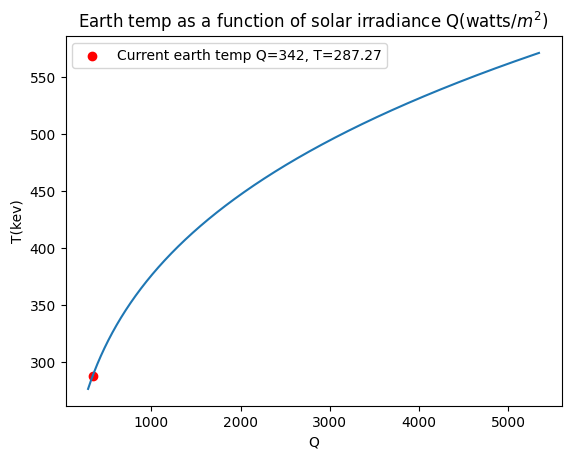

In [12]:
plt.plot(Qs, Ts)
plt.scatter(Q, T_fixed, label=f"Current earth temp Q={Q}, T={T_fixed:.2f}", color="red")
plt.title("Earth temp as a function of solar irradiance Q(watts/$m^2$)")
plt.xlabel("Q")
plt.ylabel("T(kev)")
plt.legend()

## Exploring phase space of the model

In [15]:
# set up, if u were in the ICs (same as above but with different earth temperature)
model = EnergyBalanceModel(C_earth=C_earth, alpha=alpha, Q=Q, eps=eps, sigma=sigma)

In [41]:
T0s = [T_fixed-50, T_fixed-25, T_fixed-5, T_fixed, T_fixed+5, T_fixed+25, T_fixed+50]
DAY = 24 * 60 * 60

# --- THE FIX ---
dt = DAY          # Step forward by 1 day at a time (86400 seconds)
Tn = DAY * 365*5

In [42]:
dxdt = model.rhs

In [ ]:
ax = plot_solution(dxdt, x0=T0s, tn=Tn, dt=dt, n_slope=20, slope_length=0.01, show=True, title="Evolution of earth temperature with different initial conditions of earth temperature")